<a href="https://colab.research.google.com/github/Bharatgwl/Data-Science-And-ML/blob/main/PCA_implementation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [3]:
!kaggle competitions download -c digit-recognizer

In [4]:
import zipfile
zip_ref = zipfile.ZipFile('digit-recognizer.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [5]:
import pandas as pd
df = pd.read_csv('train.csv')
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
df.sample()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
38155,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


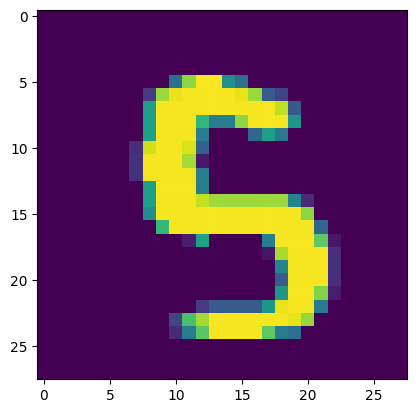

In [7]:
import matplotlib.pyplot as plt
plt.imshow(df.iloc[9876,1:].values.reshape(28,28))

In [8]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [9]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [10]:
X_train.shape

(33600, 784)

In [11]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()


In [12]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [13]:
ypred = knn.predict(X_test)

In [14]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,ypred)

0.9648809523809524

In [15]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [16]:
x_train = scaler.fit_transform(X_train)
x_test = scaler.transform(X_test)

In [17]:
from sklearn.decomposition import PCA
pca = PCA(n_components=200)
x_train_trf= pca.fit_transform(x_train)
x_test_trf =pca.transform(x_test)

In [18]:
x_train_trf.shape

(33600, 200)

In [19]:
knn = KNeighborsClassifier()

In [20]:
knn.fit(x_train_trf,y_train)

KNeighborsClassifier()

In [21]:
ypred = knn.predict(x_test_trf)

In [22]:
accuracy_score(y_test,ypred)

0.9507142857142857

In [23]:
for i in range(1,785,5):
  pca = PCA(n_components=i)
  x_train_trf= pca.fit_transform(x_train)
  x_test_trf =pca.transform(x_test)
  knn = KNeighborsClassifier()
  knn.fit(x_train_trf,y_train)
  ypred = knn.predict(x_test_trf)
  print(f"Components: {i} Accuracy: {accuracy_score(y_test,ypred)}")

Components: 1 Accuracy: 0.2580952380952381
Components: 6 Accuracy: 0.8227380952380953
Components: 11 Accuracy: 0.9116666666666666
Components: 16 Accuracy: 0.9379761904761905
Components: 21 Accuracy: 0.9438095238095238
Components: 26 Accuracy: 0.9479761904761905
Components: 31 Accuracy: 0.9507142857142857
Components: 36 Accuracy: 0.9519047619047619
Components: 41 Accuracy: 0.9522619047619048
Components: 46 Accuracy: 0.9530952380952381
Components: 51 Accuracy: 0.9545238095238096
Components: 56 Accuracy: 0.954047619047619
Components: 61 Accuracy: 0.9547619047619048
Components: 66 Accuracy: 0.9545238095238096
Components: 71 Accuracy: 0.9547619047619048
Components: 76 Accuracy: 0.9547619047619048
Components: 81 Accuracy: 0.9551190476190476
Components: 86 Accuracy: 0.9557142857142857
Components: 91 Accuracy: 0.9551190476190476
Components: 96 Accuracy: 0.9545238095238096
Components: 101 Accuracy: 0.9542857142857143
Components: 106 Accuracy: 0.9536904761904762
Components: 111 Accuracy: 0.95309

ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/IPython/core/interactiveshell.py", line 3553, in run_code
    exec(code_obj, self.user_global_ns, self.user_ns)
  File "<ipython-input-23-40e7843d8675>", line 3, in <cell line: 0>
    x_train_trf= pca.fit_transform(x_train)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/utils/_set_output.py", line 319, in wrapped
    data_to_wrap = f(self, X, *args, **kwargs)
                   ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/decomposition/_pca.py", line 468, in fit_transform
    U, S, _, X, x_is_centered, xp = self._fit(X)
                                    ^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/decomp

TypeError: object of type 'NoneType' has no len()